<a href="https://colab.research.google.com/github/aksharved/Used_Motorcycle_Price_Prediction/blob/main/MotorcyclePricesModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.base import clone
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


In [12]:
from google.colab import files

uploaded = files.upload()

Saving BIKE DETAILS.csv to BIKE DETAILS (1).csv


In [13]:
df = pd.read_csv("BIKE DETAILS.csv")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (1061, 7)


,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN


In [14]:
print("columns:")
print(df.columns)

print("general dataset information:")
df.info()

print("Missing values: " )
print(df.isnull().sum())

print("Summary statistics: ")
display(df.describe())


columns:
Index(['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven',
       'ex_showroom_price'],
      dtype='object')
general dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 58.2+ KB
Missing values: 
name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64
Summary statistics: 


,selling_price,year,km_driven,ex_showroom_price
count,1061.000000,1061.000000,1061.000000,6.260000e+02
mean,59638.151744,2013.867107,34359.833176,8.795871e+04
std,56304.291973,4.301191,51623.152702,7.749659e+04
min,5000.000000,1988.000000,350.000000,3.049000e+04
25%,28000.000000,2011.000000,13500.000000,5.485200e+04
50%,45000.000000,2015.000000,25000.000000,7.275250e+04
75%,70000.000000,2017.000000,43000.000000,8.703150e+04
max,760000.000000,2020.000000,880000.000000,1.278000e+06


In [15]:
print("seller type counts:")
print(df["seller_type"].value_counts())

print("owner counts:")
print(df["owner"].value_counts())

print("number of unique motorcycle names:", df["name"].nunique())

print("top 20 motorcycle names:")
print(df["name"].value_counts().head(20))


seller type counts:
seller_type
Individual    1055
Dealer           6
Name: count, dtype: int64
owner counts:
owner
1st owner    924
2nd owner    123
3rd owner     11
4th owner      3
Name: count, dtype: int64
number of unique motorcycle names: 279
top 20 motorcycle names:
name
Bajaj Pulsar 150                 41
Royal Enfield Classic 350        27
Honda Activa [2000-2015]         23
Honda CB Hornet 160R             22
Bajaj Pulsar 180                 20
Royal Enfield Thunderbird 350    19
Hero Honda Splendor Plus         17
Yamaha FZ S V 2.0                16
Bajaj Discover 125               16
Honda Shine                      15
Honda Activa 3G                  15
Honda CB Unicorn 150             14
TVS Apache RTR 160               14
Bajaj Pulsar 135 LS              13
Yamaha FZ16                      12
Honda Activa 5G                  12
Bajaj Discover 100               11
Hero Honda CBZ extreme           11
Bajaj Pulsar 150 [2001-2011]     11
Hero Glamour 125                 11
N

In [17]:
data = df.copy()
# let's make "age" variable
data["age"] = 2024 - data["year"]
data["brand"] = data["name"].str.split().str[0]
data["model_name"] = data["name"]
# new changed data
display(data.head())
missing_summary = pd.DataFrame({"Missing Count": data.isnull().sum(),
                                "Missing Percentage": (data.isnull().sum() / len(data)) * 100
})

display(missing_summary)



,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price,age,brand,model_name
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN,5,Royal,Royal Enfield Classic 350
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN,7,Honda,Honda Dio
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0,6,Royal,Royal Enfield Classic Gunmetal Grey
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0,9,Yamaha,Yamaha Fazer FI V 2.0 [2016-2018]
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN,13,Yamaha,Yamaha SZ [2013-2014]


,Missing Count,Missing Percentage
name,0,0.000000
selling_price,0,0.000000
year,0,0.000000
seller_type,0,0.000000
owner,0,0.000000
km_driven,0,0.000000
ex_showroom_price,435,40.999057
age,0,0.000000
brand,0,0.000000
model_name,0,0.000000


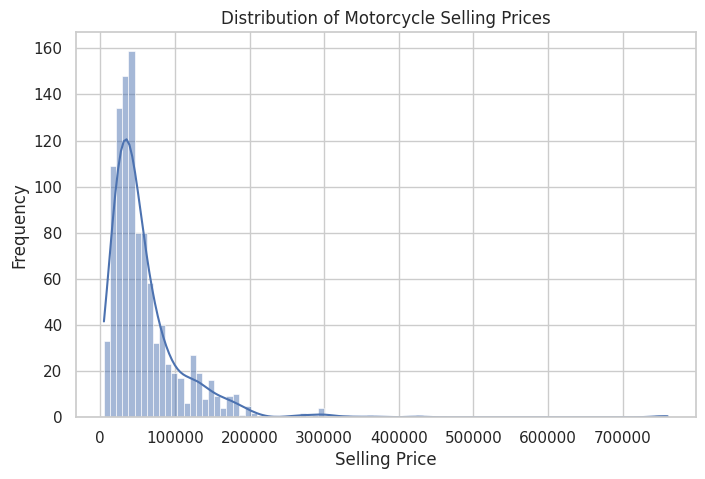

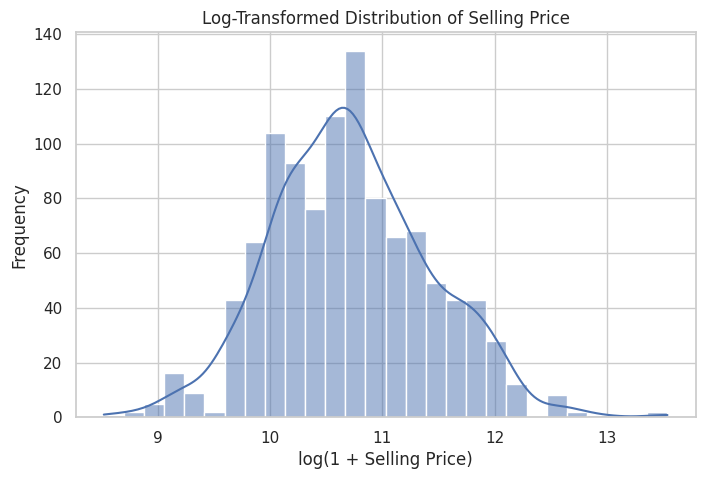

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(data["selling_price"], kde=True)
plt.title("Distribution of Motorcycle Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(data["selling_price"]), kde=True)
plt.title("Log-Transformed Distribution of Selling Price")
plt.xlabel("log(1 + Selling Price)")
plt.ylabel("Frequency")
plt.show()

# The first graph shows that motorcycle selling prices are right-skewed. Most
# motorcycles sell for relatively low or moderate prices, while a smaller number of
# motorcycles have really high prices. These expensive motorcycles stretch the
# distribution to the right. The second graph uses `log(1 + selling_price)`, which
# makes the distribution more balanced. This tells us that using a log transformation
# of the target variable may help the model handle expensive outliers more effectively.



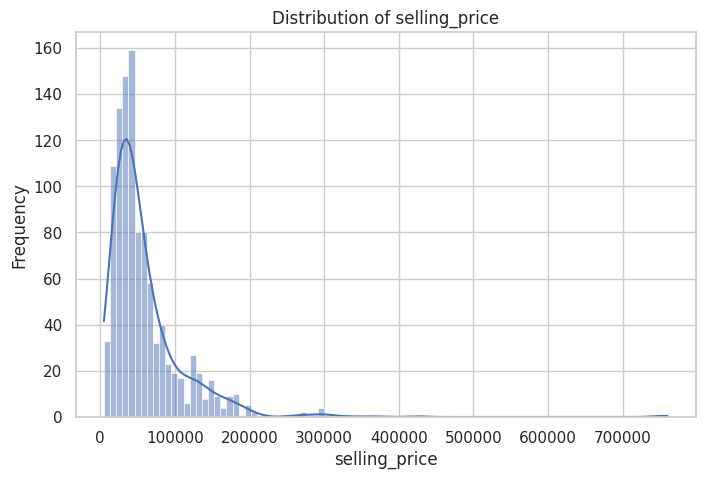

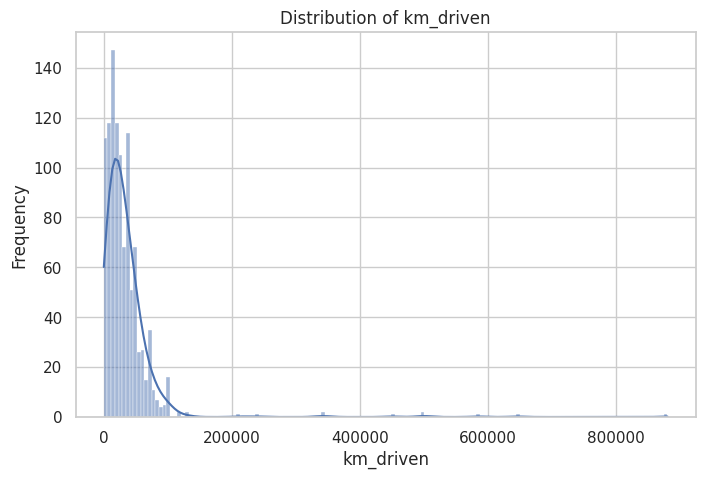

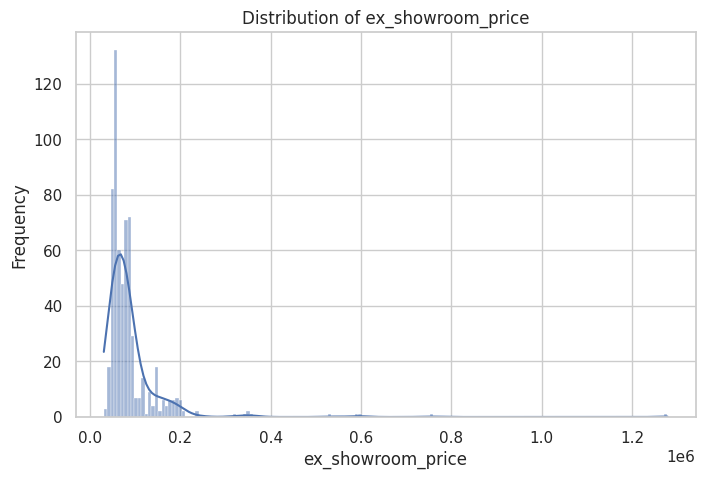

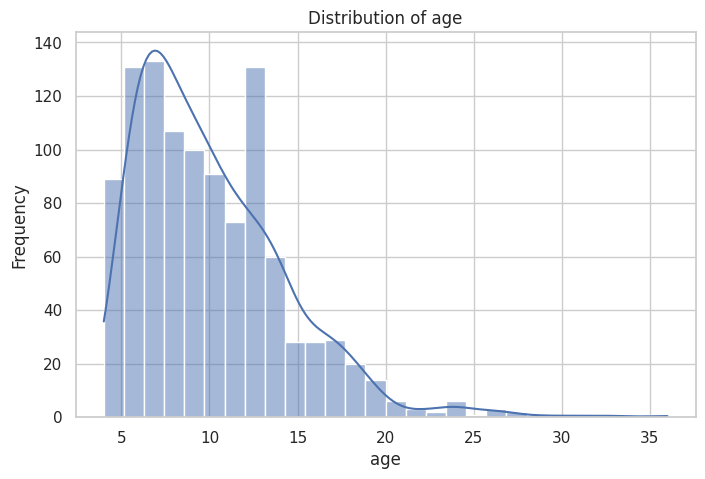

In [19]:
numeric_cols = ["selling_price", "km_driven", "ex_showroom_price", "age"]

for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()
# These histograms show the distributions of the main numeric variables: `selling_price`,
# `km_driven`, `ex_showroom_price`, and `age`. Selling price and ex-showroom price are
# strongly right-skewed, meaning most motorcycles are in lower price ranges but a few
# are much more expensive. Kilometers driven is also skewed because most motorcycles
# have moderate mileage, while a few have extremely high mileage. Age is more spread
# out, but most motorcycles are from relatively recent years. These patterns show why
# cleaning outliers and possibly transforming price are important before modeling.



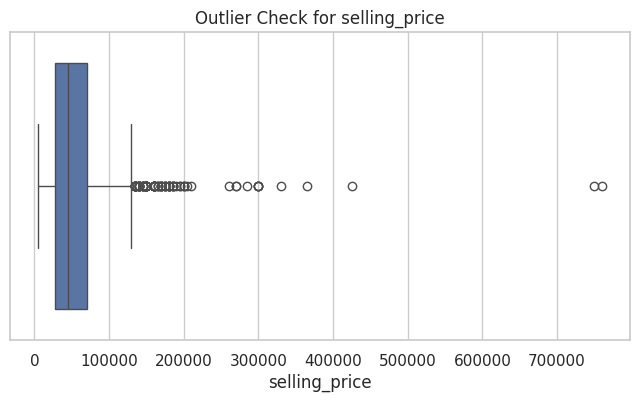

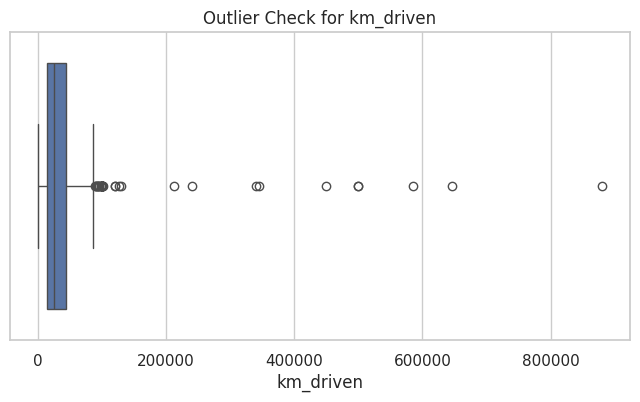

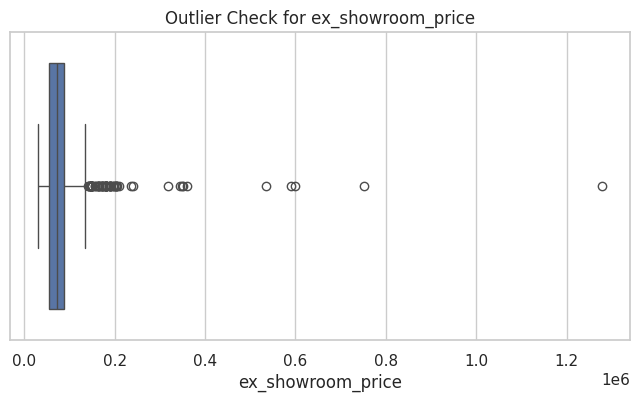

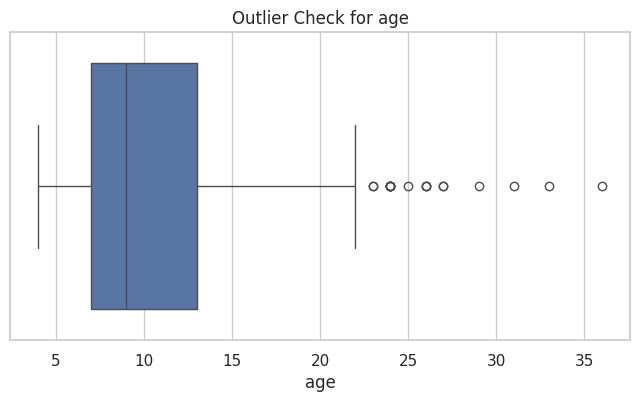

In [20]:
for col in ["selling_price", "km_driven", "ex_showroom_price", "age"]:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[col])
    plt.title(f"Outlier Check for {col}")
    plt.xlabel(col)
    plt.show()
# These boxplots help identify outliers in the numeric variables. Points far away from
# the main box represent unusually high or low values. The plots show clear outliers in
# `selling_price`, `km_driven`, and `ex_showroom_price`. For example, some motorcycles
# have extremely high mileage or very high prices compared with most listings. These
# outliers can strongly affect regression models, especially Linear Regression, so the
# dataset is later filtered to remove unrealistic or extreme values.


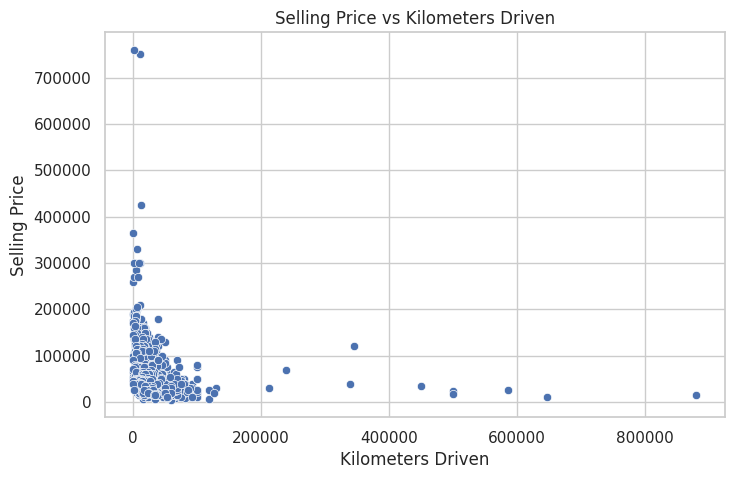

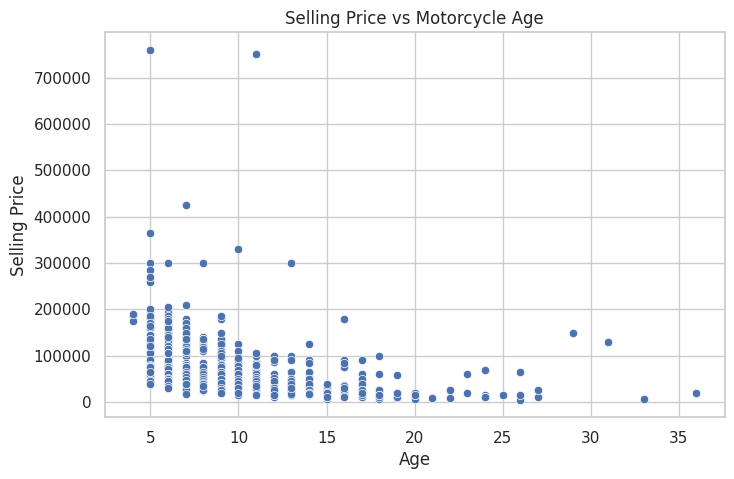

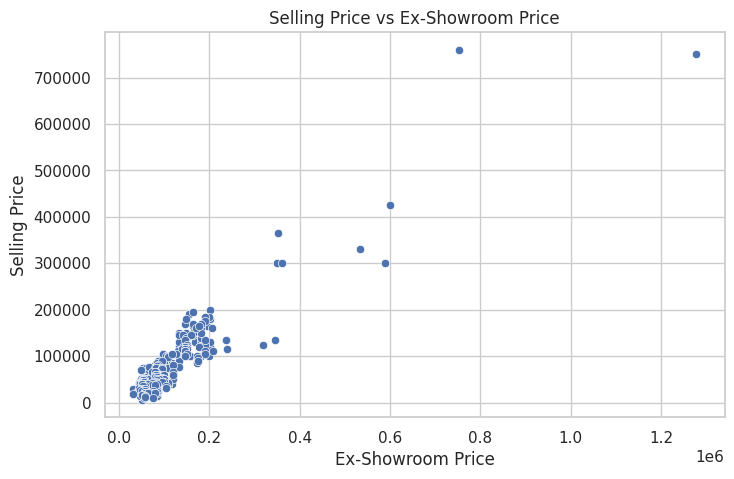

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="km_driven", y="selling_price")
plt.title("Selling Price vs Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="age", y="selling_price")
plt.title("Selling Price vs Motorcycle Age")
plt.xlabel("Age")
plt.ylabel("Selling Price")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="ex_showroom_price", y="selling_price")
plt.title("Selling Price vs Ex-Showroom Price")
plt.xlabel("Ex-Showroom Price")
plt.ylabel("Selling Price")
plt.show()
# These scatterplots show how selling price relates to mileage, age, and ex-showroom
# price. The `km_driven` plot suggests that motorcycles with very high mileage often
# have lower selling prices, although the relationship is not perfectly linear. The
# `age` plot shows that older motorcycles generally tend to sell for less, which matches
# the idea of depreciation. The `ex_showroom_price` plot shows a positive relationship:
# motorcycles that were more expensive when new often have higher resale prices.
# However, the points are spread out, which means price depends on multiple features,
# not just one variable.


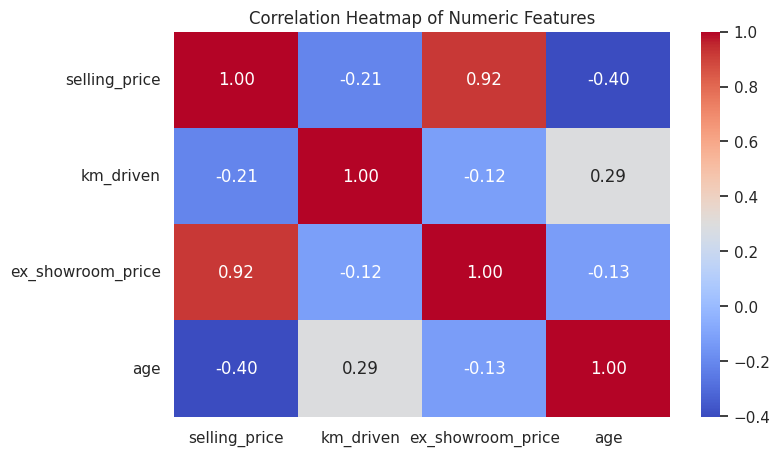

In [22]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    data[["selling_price", "km_driven", "ex_showroom_price", "age"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()
# The heatmap shows the linear correlation between numeric variables. `ex_showroom_price` is positively
# related to `selling_price`, which makes sense because motorcycles that cost more when
# new usually resell for more. `age` and `km_driven` tend to have weaker or negative
# relationships with selling price, meaning older or more heavily used motorcycles often
# sell for less. Since the correlations are not perfect, nonlinear models like Random
# Forest and Gradient Boosting may capture patterns that Linear Regression misses.



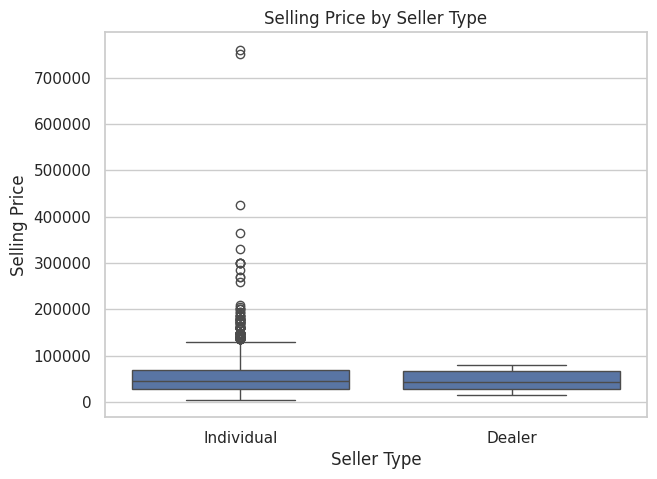

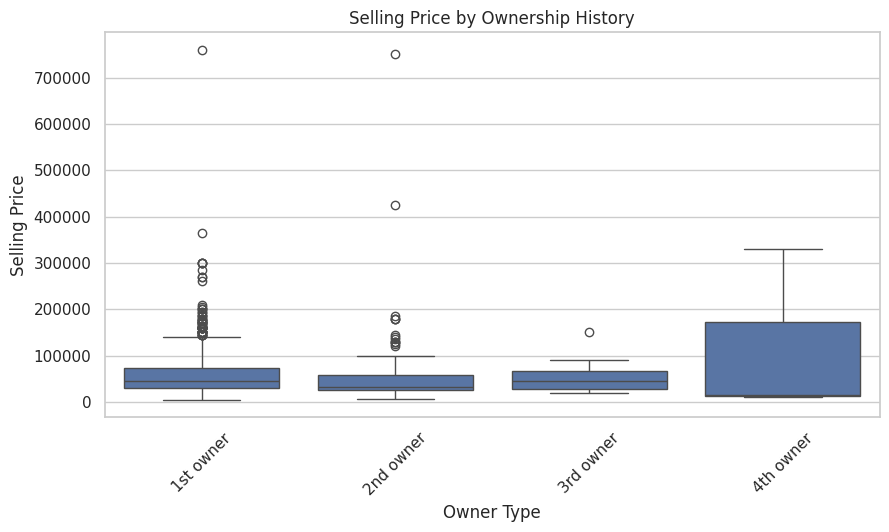

In [23]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=data, x="seller_type", y="selling_price")
plt.title("Selling Price by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Selling Price")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="owner", y="selling_price")
plt.title("Selling Price by Ownership History")
plt.xlabel("Owner Type")
plt.ylabel("Selling Price")
plt.xticks(rotation=45)
plt.show()
# These boxplots compare selling price across categorical variables. The seller type
# plot compares individual sellers and dealers, but the dataset has very few dealer
# listings, so that comparison should be interpreted carefully. The ownership plot shows
# how price changes by ownership history. First-owner motorcycles generally appear to
# have higher resale prices than motorcycles with more previous owners. This matches
# real-world expectations because buyers usually value motorcycles more when they have
# had fewer owners.


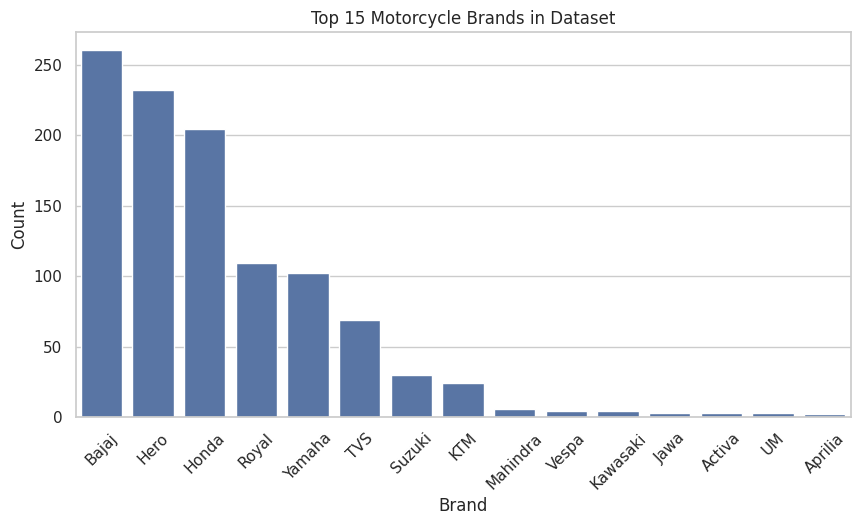

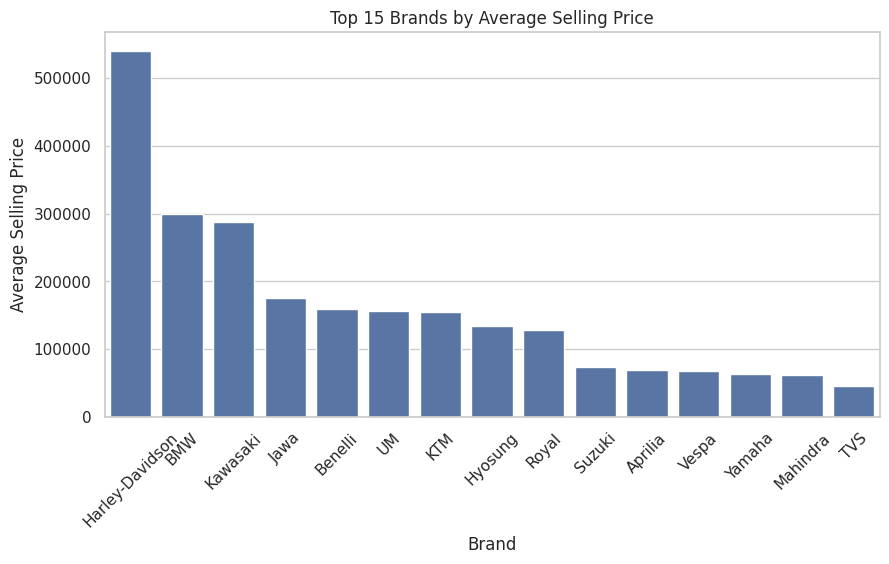

In [24]:
top_brands = data["brand"].value_counts().head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_brands.index, y=top_brands.values)
plt.title("Top 15 Motorcycle Brands in Dataset")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

brand_avg_price = (
    data.groupby("brand")["selling_price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=brand_avg_price.index, y=brand_avg_price.values)
plt.title("Top 15 Brands by Average Selling Price")
plt.xlabel("Brand")
plt.ylabel("Average Selling Price")
plt.xticks(rotation=45)
plt.show()


In [27]:
# data cleaning
clean_data = data[
    (data["selling_price"] > 0) &
    (data["selling_price"] < 800000) &
    (data["km_driven"] >= 0) &
    (data["km_driven"] < 300000) &
    (data["age"] >= 0) &
    (data["age"] <= 30)
].copy()

print("Original dataset shape:", data.shape)
print("Cleaned dataset shape:", clean_data.shape)
print("Rows removed:", data.shape[0] - clean_data.shape[0])

display(clean_data.head())


Original dataset shape: (1061, 10)
Cleaned dataset shape: (1050, 10)
Rows removed: 11


,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price,age,brand,model_name
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN,5,Royal,Royal Enfield Classic 350
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN,7,Honda,Honda Dio
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0,6,Royal,Royal Enfield Classic Gunmetal Grey
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0,9,Yamaha,Yamaha Fazer FI V 2.0 [2016-2018]
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN,13,Yamaha,Yamaha SZ [2013-2014]


In [28]:
# we make sure to split the dataset into training and testing before clustering to prevent leakage
base_features = ["km_driven", "ex_showroom_price", "age", "seller_type", "owner", "brand"]

X_base = clean_data[base_features].copy()
y = clean_data["selling_price"].copy()

X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.20,
    random_state=42
)

cluster_features = ["km_driven", "ex_showroom_price", "age", "seller_type", "owner", "brand"]

numeric_cluster_features = ["km_driven", "ex_showroom_price", "age"]
categorical_cluster_features = ["seller_type", "owner", "brand"]

cluster_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cluster_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

cluster_preprocessor = ColumnTransformer(
    transformers=[
        ("num", cluster_numeric_transformer, numeric_cluster_features),
        ("cat", cluster_categorical_transformer, categorical_cluster_features)
    ]
)

X_cluster_train_processed = cluster_preprocessor.fit_transform(X_train_base[cluster_features])
X_cluster_test_processed = cluster_preprocessor.transform(X_test_base[cluster_features])

print("Base training set:", X_train_base.shape)
print("Base testing set:", X_test_base.shape)


Base training set: (840, 6)
Base testing set: (210, 6)


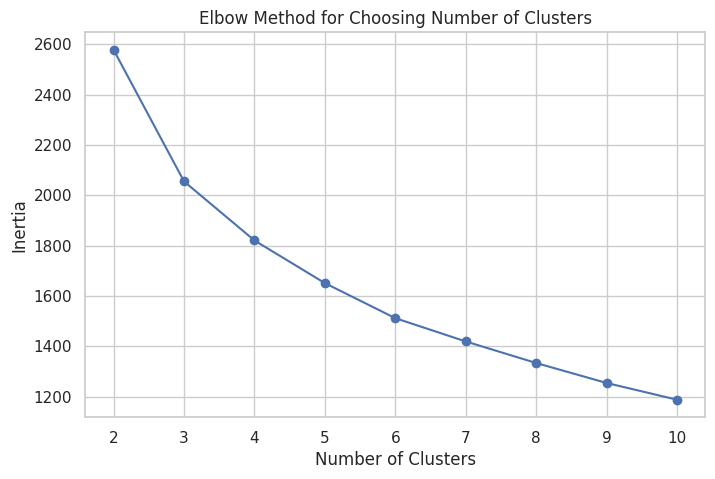

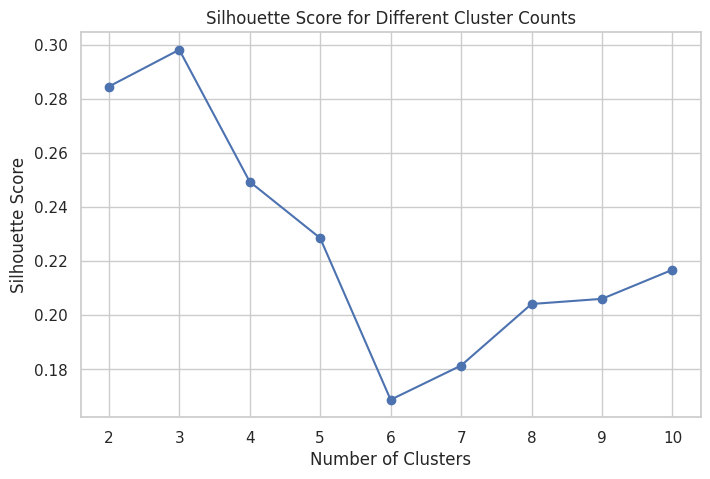

,k,Inertia,Silhouette Score
0,2,2577.794904,0.284473
1,3,2055.083631,0.298079
2,4,1820.568049,0.249334
3,5,1651.092857,0.228513
4,6,1511.924841,0.168802
5,7,1419.513484,0.181443
6,8,1333.842254,0.204171
7,9,1254.566266,0.206074
8,10,1188.097395,0.216807


In [29]:
inertias = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans_candidate = KMeans(n_clusters=k, random_state=42, n_init=10)
    train_cluster_labels = kmeans_candidate.fit_predict(X_cluster_train_processed)

    inertias.append(kmeans_candidate.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_train_processed, train_cluster_labels))

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Method for Choosing Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.title("Silhouette Score for Different Cluster Counts")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

silhouette_df = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

display(silhouette_df)
# Based on the elbow and silhouette plots, we selected 3 clusters. The silhouette score is highest when k = 3,
# meaning the clusters are most clearly separated at this value. The elbow plot also shows that inertia decreases
# substantially up to around 3 clusters, after which the improvement becomes more gradual. Therefore, 3 clusters
# provides a good balance between model simplicity and meaningful grouping.


In [30]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

train_clusters = kmeans.fit_predict(X_cluster_train_processed)
test_clusters = kmeans.predict(X_cluster_test_processed)

X_train = X_train_base.copy()
X_test = X_test_base.copy()

X_train["cluster"] = train_clusters.astype(str)
X_test["cluster"] = test_clusters.astype(str)

clean_data = clean_data.copy()
clean_data["cluster"] = np.nan
clean_data.loc[X_train.index, "cluster"] = X_train["cluster"]
clean_data.loc[X_test.index, "cluster"] = X_test["cluster"]

X = pd.concat([X_train, X_test]).sort_index()
y = clean_data["selling_price"]

print("Training cluster counts:")
print(X_train["cluster"].value_counts().sort_index())

print("\nTesting cluster counts:")
print(X_test["cluster"].value_counts().sort_index())

print("\nOverall cluster counts:")
print(clean_data["cluster"].value_counts().sort_index())


Training cluster counts:
cluster
0    556
1    279
2      5
Name: count, dtype: int64

Testing cluster counts:
cluster
0    143
1     67
Name: count, dtype: int64

Overall cluster counts:
cluster
0    699
1    346
2      5
Name: count, dtype: int64
